# Automobile Customer Segmentation with K-Means and PCA

## Business use case

Automotive brands often collect preference surveys that are difficult to turn into clear customer strategies. Unsupervised segmentation can group respondents with similar priorities so product, messaging, and research teams can reason about a smaller set of preference profiles.

## Objective

This notebook explores 12 survey attributes across 793 respondents, studies relationships among those attributes, selects a cluster count with the elbow method, fits K-Means, and uses PCA to visualize the resulting segments.

## Result in context

The saved workflow selects **two clusters**. Because the source features are binary indicators on a common scale, raw-feature K-Means provides a reasonable exploratory baseline.

## Step 1 — Prepare the clustering environment

Pandas, NumPy, visualization libraries, K-Means, and PCA provide the exploratory and unsupervised-learning toolkit.


In [1]:
!pip install plotly
!pip install bioinfokit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bioinfokit: filename=bioinfokit-2.1.4-py3-none-any.whl size=59308 sha256=a054363fe6edff7fba05060137c542bd03efc0bcc5094acd18e27cc362da9b5e
  Stored in directory: /root/.cache/pip/wheels/fc/51/ce/c3421fa3b4a59ff5310d04e082636ffde48c5575dba558cd49
Successfully built bioinfokit


In [2]:
### import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.figure_factory as ff
from matplotlib import cm
from bioinfokit.visuz import cluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Step 2 — Load and inspect the survey matrix

The dataset contains **793 rows and 12 features**, including preferences such as technology, comfort, reliability, handling, safety, sportiness, and household-related indicators.


In [3]:
dataframe = pd.read_csv('/data/autoSurvey.csv')
#Preview the dataset
dataframe.head()

,driving_properties,interior,technology,comfort,reliability,handling,power,consumption,sporty,safety,gender,household
0,0,0,1,0,1,0,0,0,1,1,0,1
1,1,0,0,0,0,1,0,0,0,1,0,1
2,1,0,0,1,0,0,1,0,1,1,0,1
3,0,1,0,1,1,0,0,0,1,1,0,0
4,0,1,1,1,0,0,0,0,0,0,0,0


In [4]:
dataframe.shape

(793, 12)

## Step 3 — Explore dependence and hierarchical structure

Covariance, a dendrogram, and a clustered heatmap provide complementary views of which attributes and respondents move together before committing to K-Means.


In [5]:
# Calculate covariance directly on the original data using the pandas method
covMatrix = dataframe.cov()
print("Covariance Matrix")
print(covMatrix)

Covariance Matrix
                    driving_properties  interior  technology   comfort  \
driving_properties            0.214252 -0.001904    0.017619  0.019629   
interior                     -0.001904  0.185668   -0.003250  0.033159   
technology                    0.017619 -0.003250    0.246570  0.018734   
comfort                       0.019629  0.033159    0.018734  0.237845   
reliability                  -0.002753 -0.013785   -0.003312  0.003498   
handling                      0.026085  0.001511    0.005843 -0.012273   
power                         0.042125 -0.011881    0.033750 -0.008458   
consumption                   0.001229  0.005154    0.008732  0.001458   
sporty                        0.028029  0.003250   -0.000941 -0.008147   
safety                        0.000427 -0.001201    0.017535  0.018785   
gender                       -0.008585 -0.006375   -0.006948  0.002485   
household                     0.009458  0.002111    0.004020 -0.001463   

                   

In [6]:
covMatrix.shape

(12, 12)

In [7]:
np.random.seed(1)

fig = ff.create_dendrogram(dataframe, color_threshold = 1.5)
fig.update_layout(width=800, height=500)
fig.show()

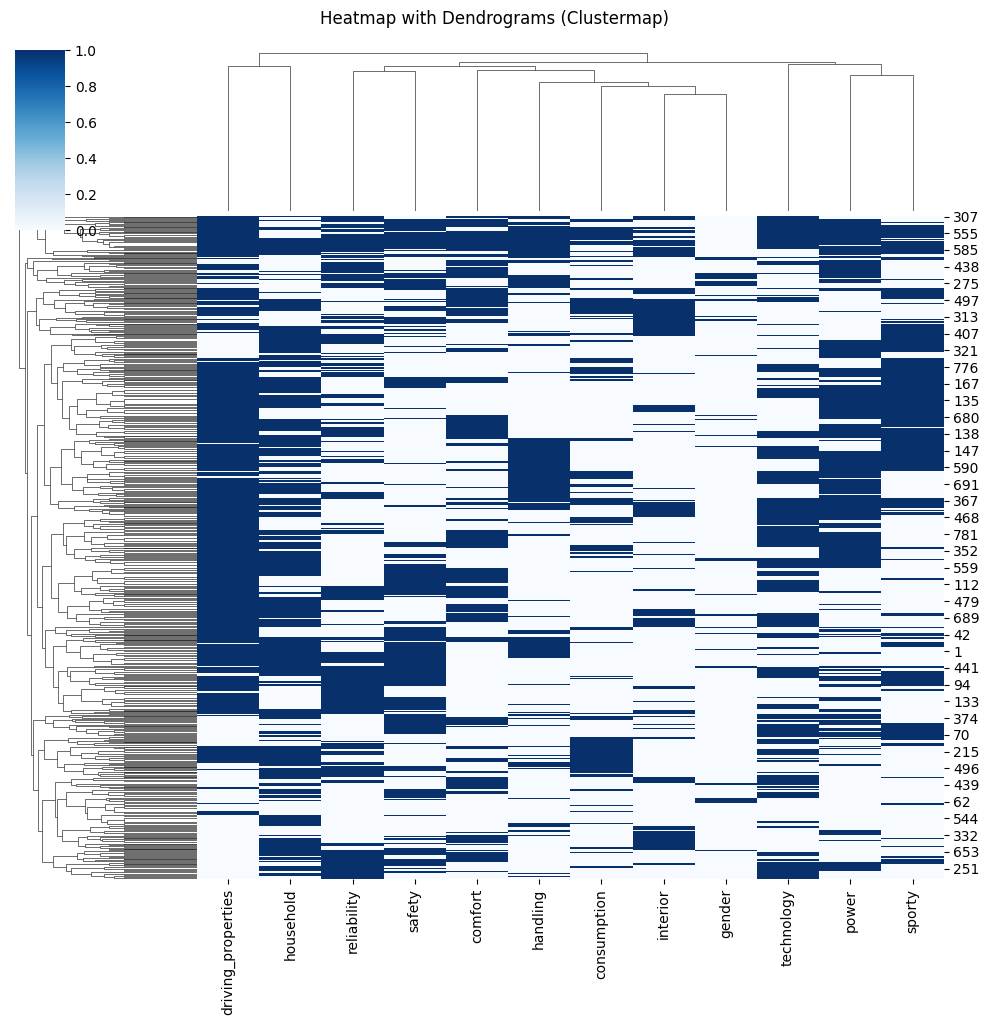

In [8]:
# Generate the clustermap on the raw data
sns.clustermap(dataframe, cmap='Blues')
plt.suptitle("Heatmap with Dendrograms (Clustermap)", y=1.02)
plt.show()

## Step 4 — Review correlation structure

Correlation heatmaps and the 3D correlation surface make redundant or strongly associated survey dimensions easier to spot. This step helps explain whether several variables may be describing the same underlying preference.


In [9]:
dataframe.corr()

,driving_properties,interior,technology,comfort,reliability,handling,power,consumption,sporty,safety,gender,household
driving_properties,1.000000,-0.009548,0.076658,0.086953,-0.012086,0.123953,0.181943,0.006081,0.123169,0.001881,-0.076985,0.041540
interior,-0.009548,1.000000,-0.015188,0.157794,-0.065011,0.007713,-0.055124,0.027391,0.015340,-0.005684,-0.061410,0.009961
technology,0.076658,-0.015188,1.000000,0.077359,-0.013553,0.025883,0.135882,0.040267,-0.003854,0.072045,-0.058081,0.016460
comfort,0.086953,0.157794,0.077359,1.000000,0.014575,-0.055350,-0.034671,0.006848,-0.033980,0.078583,0.021153,-0.006100
reliability,-0.012086,-0.065011,-0.013553,0.014575,1.000000,-0.003793,-0.005213,0.010595,-0.001968,0.126057,0.009776,-0.084570
handling,0.123953,0.007713,0.025883,-0.055350,-0.003793,1.000000,0.166429,0.081824,0.078576,0.015061,-0.003154,0.030380
power,0.181943,-0.055124,0.135882,-0.034671,-0.005213,0.166429,1.000000,0.055930,0.215446,-0.062325,-0.041645,-0.043481
consumption,0.006081,0.027391,0.040267,0.006848,0.010595,0.081824,0.055930,1.000000,-0.021670,-0.024473,-0.078528,0.034920
sporty,0.123169,0.015340,-0.003854,-0.033980,-0.001968,0.078576,0.215446,-0.021670,1.000000,-0.053016,-0.031535,0.020726
safety,0.001881,-0.005684,0.072045,0.078583,0.126057,0.015061,-0.062325,-0.024473,-0.053016,1.000000,0.057868,-0.023471


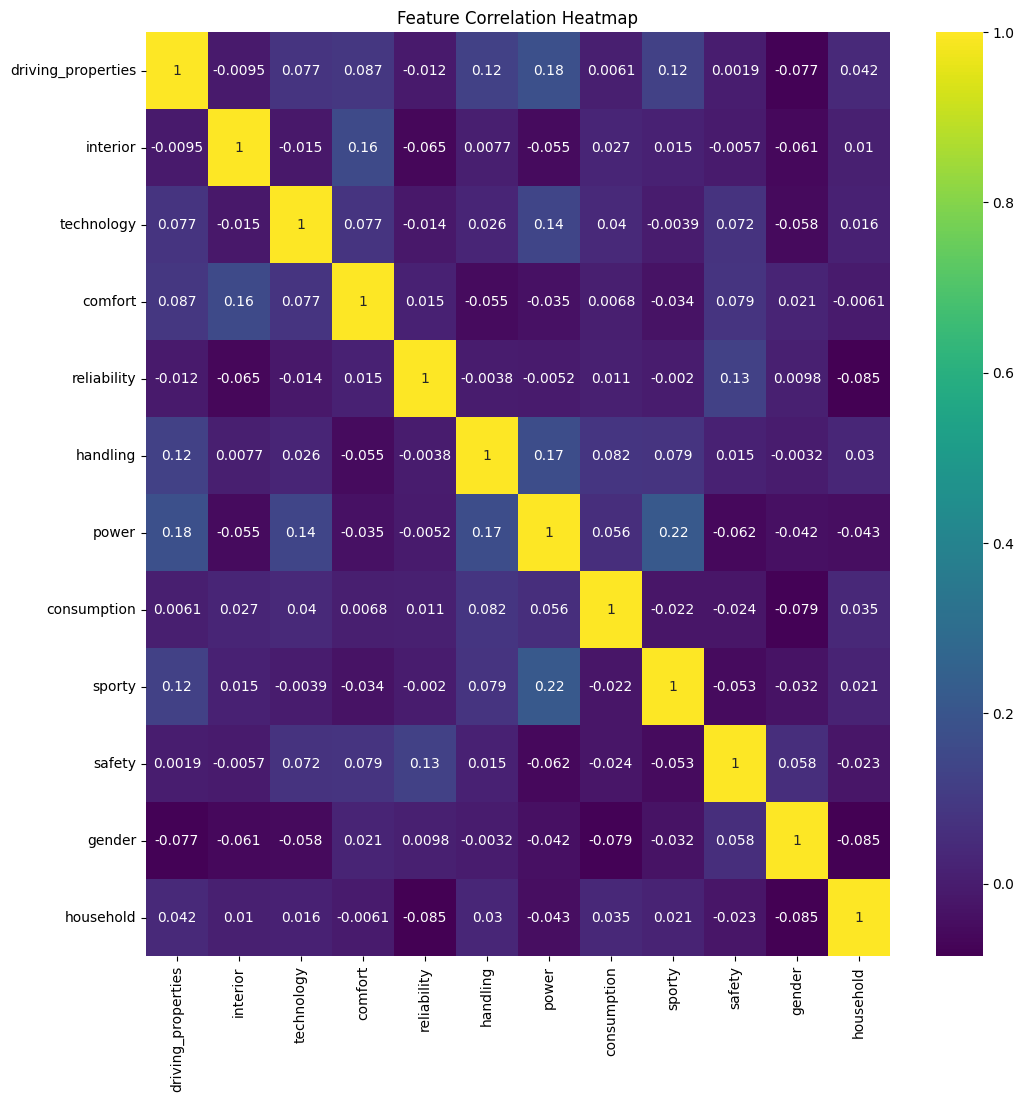

In [10]:
# generating correlation heatmap
plt.figure(figsize=(12,12))
sns.heatmap(dataframe.corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation Heatmap")
plt.show()

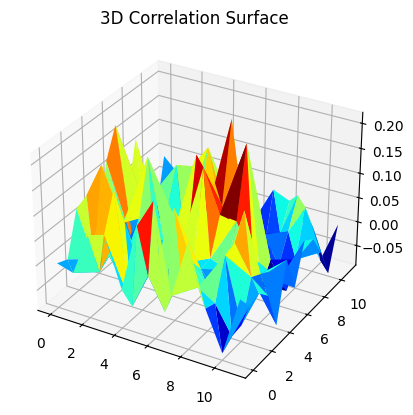

In [11]:
# Prepare correlation data
data = dataframe.corr()
data.index = range(len(data))
data.rename(columns=dict(zip(data.columns, data.index)), inplace=True)

# Convert to 3D coordinates
df_list = []
for i in range(len(data)):
    for j in range(len(data)):
        df_list.append((i, j, data.iloc[i, j] if i != j else 0))

plot_df = pd.DataFrame(df_list)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(plot_df[0], plot_df[1], plot_df[2], cmap=cm.jet, linewidth=0.2)
plt.title("3D Correlation Surface")
plt.show()

## Step 5 — Select the number of clusters

Within-cluster sum of squares is computed across candidate values of `k`. The stored notebook uses the elbow plot to select **k = 2**.


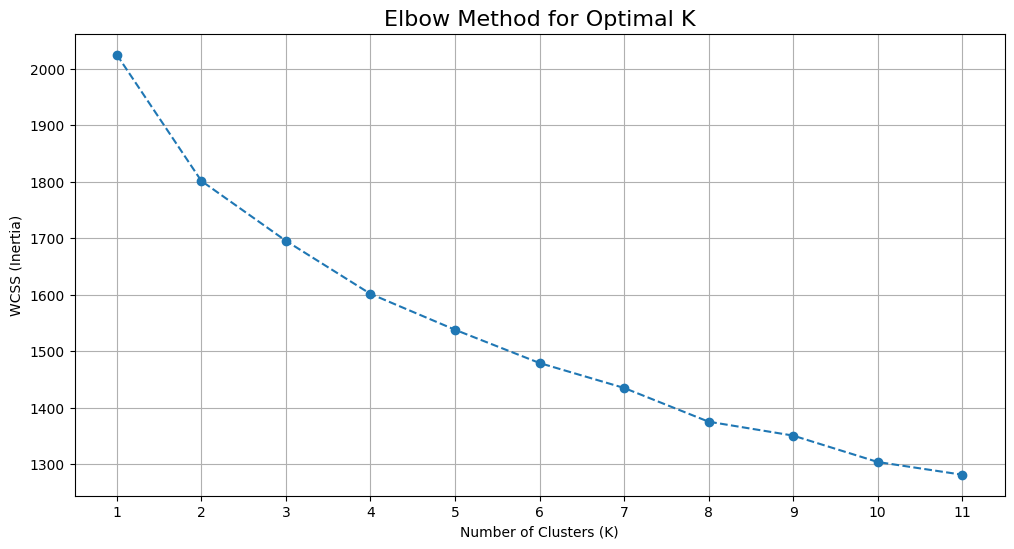

In [12]:
wcss = []
possible_k = range(1, 12)

# Prepare the input data (all feature columns)
x_input = dataframe.values

for k in possible_k:
    k_means = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    k_means.fit(x_input) # Fit on RAW data
    wcss.append(k_means.inertia_)

# Plotting code
plt.figure(figsize=(12, 6))
plt.plot(possible_k, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=16)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(possible_k)
plt.grid(True)
plt.show()

## Step 6 — Fit K-Means and attach segment labels

K-Means is trained on the original survey features and the resulting cluster label is added back to the respondent-level data for downstream profiling.


In [13]:
# Prepare the input data
x_input = dataframe.values

# Choose the number of clusters based on the elbow plot
n_clusters = 2

kmeans = KMeans(n_clusters, init='k-means++', random_state=42, n_init=10)

# Fit the model and predict clusters on the RAW data
y_kmeans = kmeans.fit_predict(x_input)

# Add the cluster assignments back to the original dataframe for analysis
dataframe['Cluster'] = y_kmeans

print("DataFrame with Cluster Assignments:")
print(dataframe.head())

DataFrame with Cluster Assignments:
   driving_properties  interior  technology  comfort  reliability  handling  \
0                   0         0           1        0            1         0   
1                   1         0           0        0            0         1   
2                   1         0           0        1            0         0   
3                   0         1           0        1            1         0   
4                   0         1           1        1            0         0   

   power  consumption  sporty  safety  gender  household  Cluster  
0      0            0       1       1       0          1        0  
1      0            0       0       1       0          1        0  
2      1            0       1       1       0          1        1  
3      0            0       1       1       0          0        0  
4      0            0       0       0       0          0        0  


In [16]:
# Analyzing mean of the clusters
dataframe.groupby('Cluster').mean()

,driving_properties,interior,technology,comfort,reliability,handling,power,consumption,sporty,safety,gender,household
Cluster,,,,,,,,,,,,
0,0.607407,0.269136,0.372840,0.404938,0.412346,0.217284,0.0,0.232099,0.303704,0.429630,0.071605,0.612346
1,0.775773,0.221649,0.507732,0.371134,0.407216,0.368557,1.0,0.280928,0.515464,0.368557,0.051546,0.569588


## Step 7 — Visualize segments with PCA

PCA compresses the 12-dimensional feature space into two dimensions for plotting. The biplot also helps connect separation in PCA space with the original survey attributes.


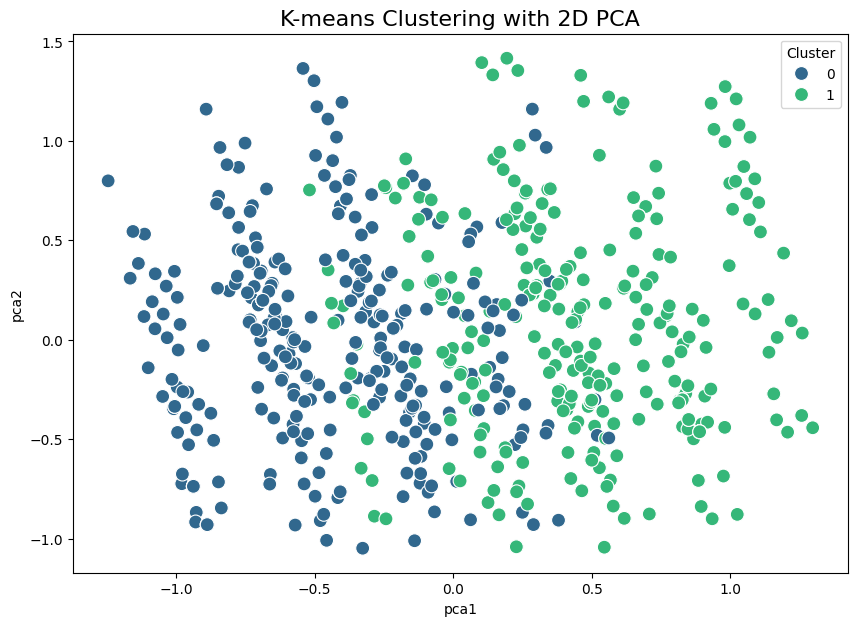

In [14]:
# Select only the original feature columns for PCA
features = dataframe.drop('Cluster', axis=1)

pca = PCA(n_components=2)

# Run PCA on the RAW feature data
reduced_data = pca.fit_transform(features)

# Create a new DataFrame with the PCA results and add cluster labels
results = pd.DataFrame(reduced_data, columns=['pca1', 'pca2'])
results['Cluster'] = dataframe['Cluster']

# Plotting code
plt.figure(figsize=(10, 7))
sns.scatterplot(x="pca1", y="pca2", hue='Cluster', data=results, palette='viridis', s=100)
plt.title('K-means Clustering with 2D PCA', fontsize=16)
plt.show()

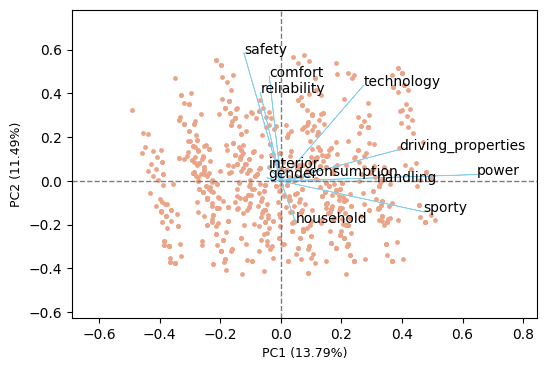

In [15]:
df = dataframe.iloc[: , :-1]
pca_out = PCA(n_components=2).fit(df)

loadings = pca_out.components_
pca_out.explained_variance_ratio_

cluster.biplot(show = True, cscore=reduced_data, loadings=loadings, labels=df.columns.values,
               var1=round(pca_out.explained_variance_ratio_[0]*100, 2), var2=round(pca_out.explained_variance_ratio_[1]*100, 2))

## Technical conclusions

The workflow produces a two-cluster segmentation and uses hierarchical clustering plus PCA as independent visual checks. Because the input variables are binary and share the same scale, feature-scale distortion is less severe than it would be with mixed continuous units. It can also be seen a profile table of feature means by segment that confirms that the two clusters are separated by the power attribute.

## Business conclusions

The segmentation becomes useful after each cluster translating it into a clear customer profile. In this case, ase the most important feature is power, the two groups would be customers that want a powered vehicle and customers that do not need it. Other attributes that have more tendecy to be in the powered vehicles group are technology, sporty, handling and driving properties. The opposite attributes are mostly transversal and can be found in similar numbers on both groups. These detected profiles will inform campaign targeting, product research, or differentiated messaging.

## Limitations and next steps

K-Means assumes roughly spherical clusters and uses Euclidean distance. For binary survey data, I would also compare alternative similarity measures or clustering methods and test whether the segments remain stable.
